# 02 - Missing Data Analysis

Displays the already-computed missingness summary and figures for the three
implemented mechanisms (MCAR, MAR, MNAR) at 10/20/30%. No new masking is
performed here; all numbers come from `results/tables/missingness_summary.csv`.

**MCAR** (Missing Completely at Random): eligible cells masked independently
at random, with no dependence on any observed or unobserved variable.

**MAR** (Missing at Random): the probability of a cell being masked is
conditioned on other *observed* variables, with the exact conditioning
variables and direction documented in `docs/experiment_log.md`.

**MNAR** (Missing Not at Random): the probability of a cell being masked is
conditioned on the value being masked itself, again documented per feature.

All three mechanisms are scoped to the seven continuous features; the target
column and the five binary clinical flags are never masked.

In [1]:
import pandas as pd
from IPython.display import Image, display

summary = pd.read_csv("../results/tables/missingness_summary.csv")
summary

,mechanism,requested_pct,column,actual_pct
0,MCAR,10,age,10.04
1,MCAR,10,creatinine_phosphokinase,10.04
2,MCAR,10,ejection_fraction,10.04
3,MCAR,10,platelets,10.04
4,MCAR,10,serum_creatinine,10.04
...,...,...,...,...
58,MNAR,30,serum_sodium,30.13
59,MNAR,30,age,30.13
60,MNAR,30,creatinine_phosphokinase,30.13
61,MNAR,30,platelets,30.13


In [2]:
summary.pivot_table(index="column", columns=["mechanism", "requested_pct"], values="actual_pct")

mechanism                   MAR                 MCAR                 MNAR  \
requested_pct                10     20     30     10     20     30     10   
column                                                                      
age                       10.04  20.08  30.13  10.04  20.08  30.13  10.04   
creatinine_phosphokinase  10.04  20.08  30.13  10.04  20.08  30.13  10.04   
ejection_fraction         10.04  20.08  30.13  10.04  20.08  30.13  10.04   
platelets                 10.04  20.08  30.13  10.04  20.08  30.13  10.04   
serum_creatinine          10.04  20.08  30.13  10.04  20.08  30.13  10.04   
serum_sodium              10.04  20.08  30.13  10.04  20.08  30.13  10.04   
time                      10.04  20.08  30.13  10.04  20.08  30.13  10.04   

mechanism                               
requested_pct                20     30  
column                                  
age                       20.08  30.13  
creatinine_phosphokinase  20.08  30.13  
ejection_fraction         20.08  30.13  
platelets                 20.08  30.13  
serum_creatinine          20.08  30.13  
serum_sodium              20.08  30.13  
time                      20.08  30.13

## Missingness figures (20% level shown, all three mechanisms)

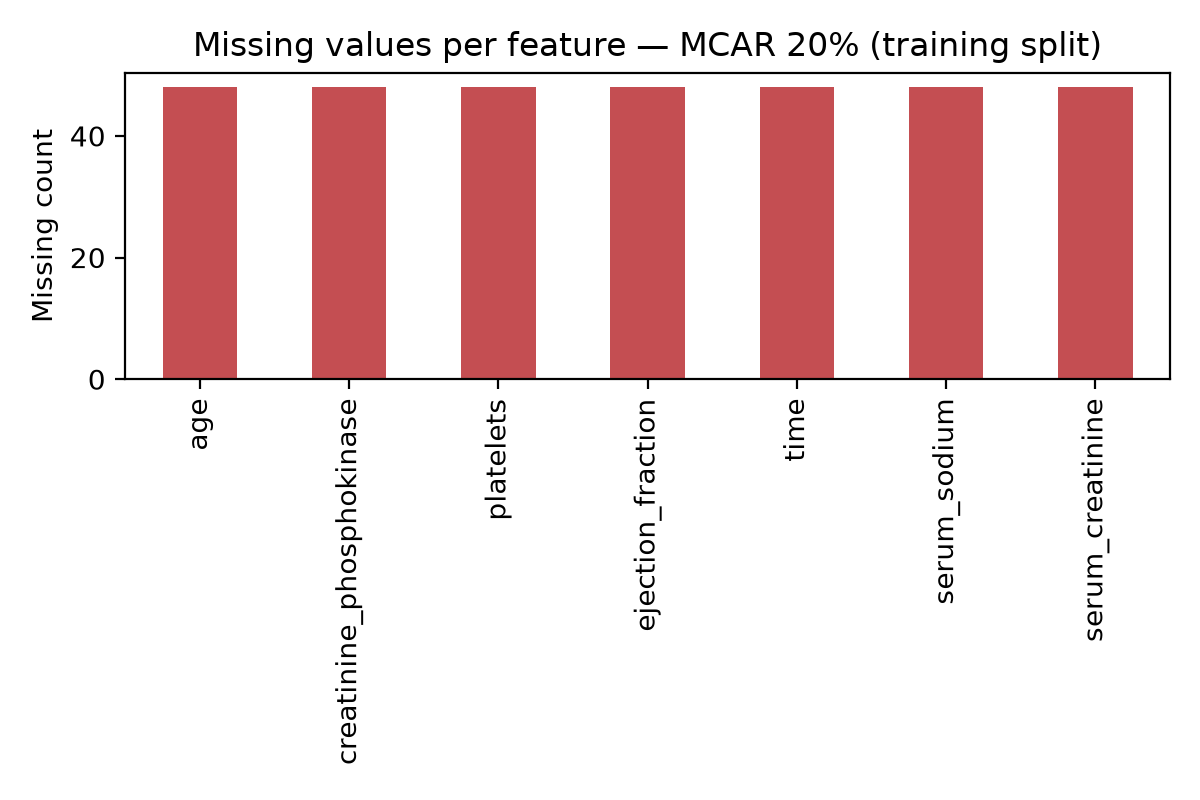

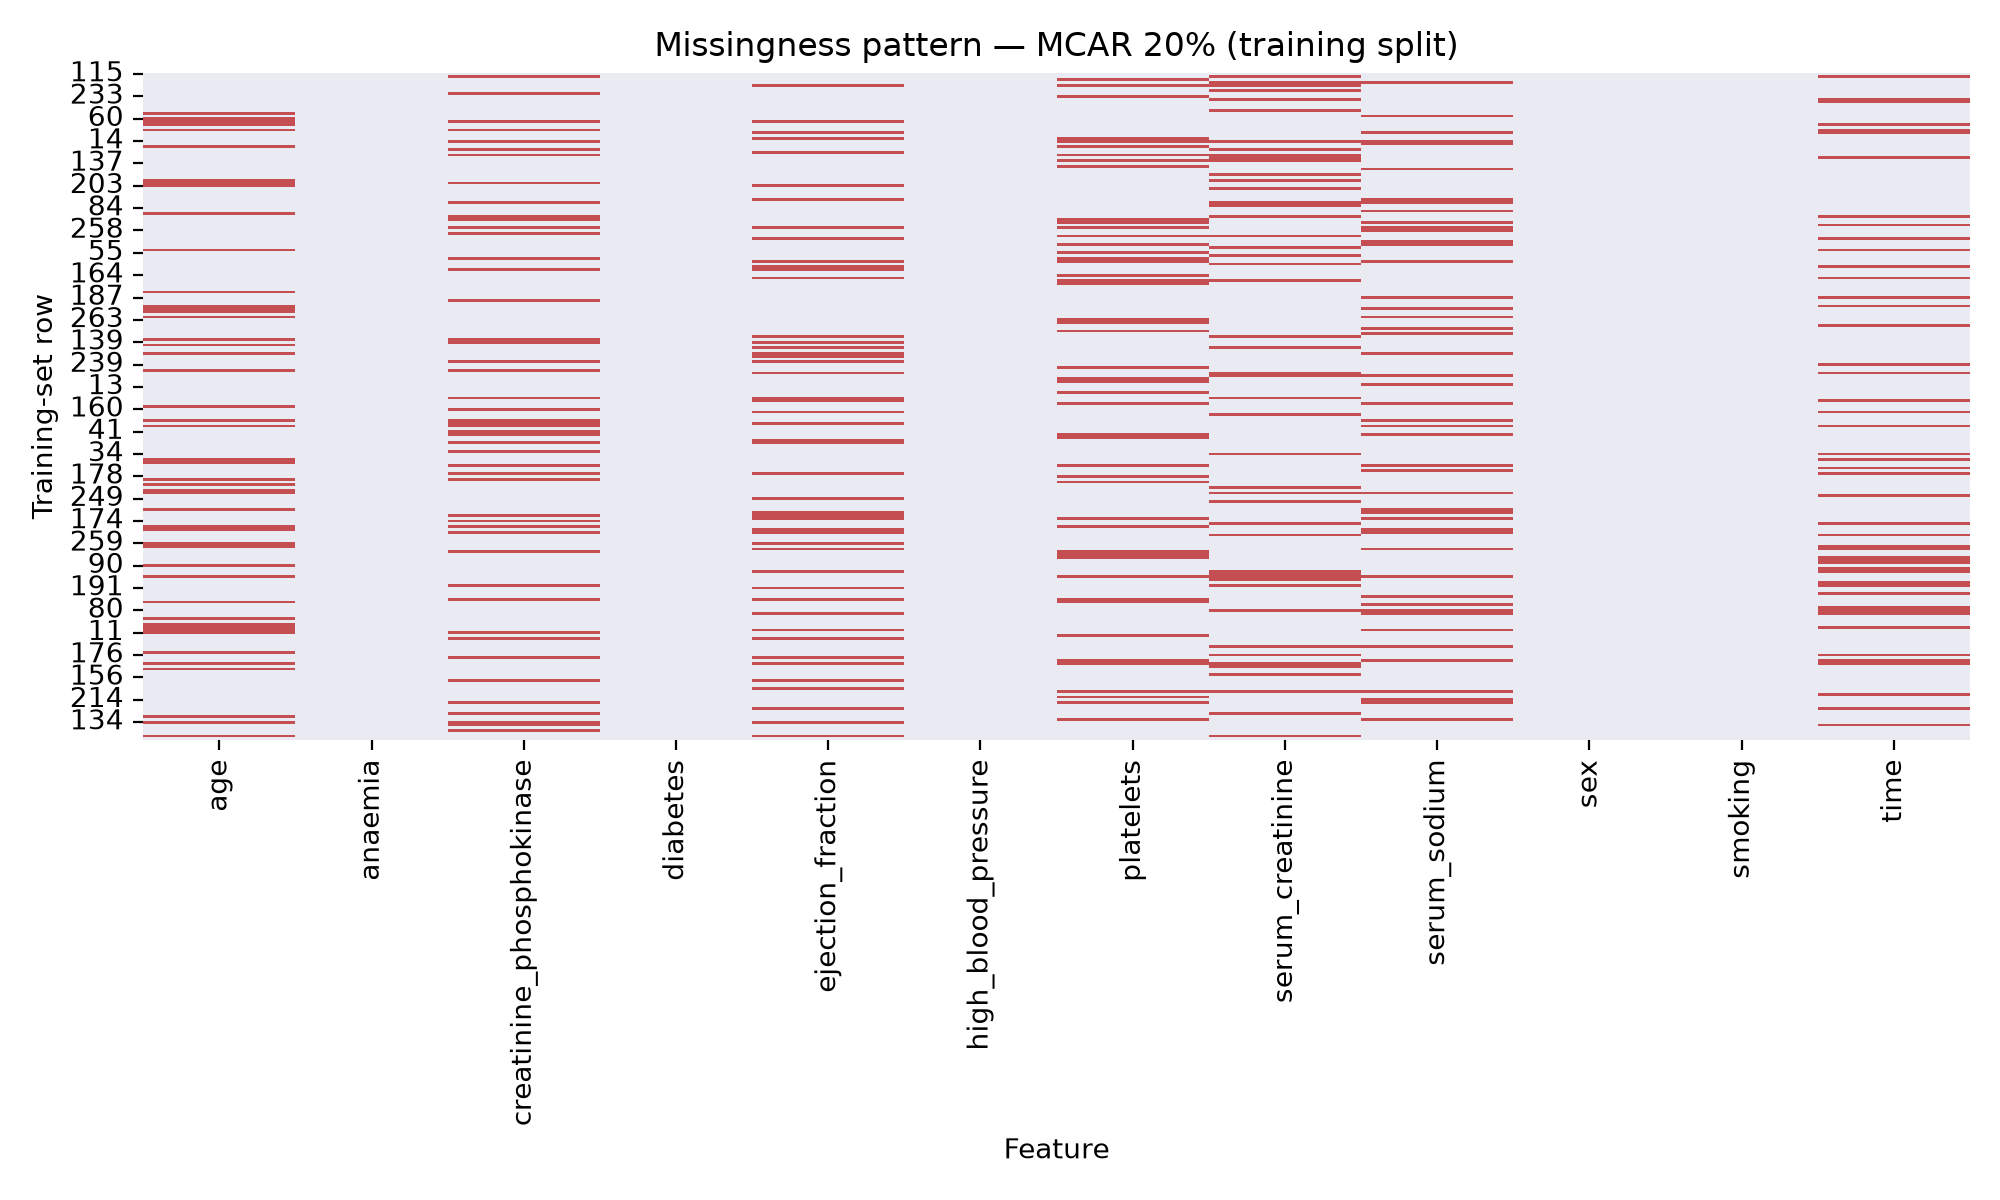

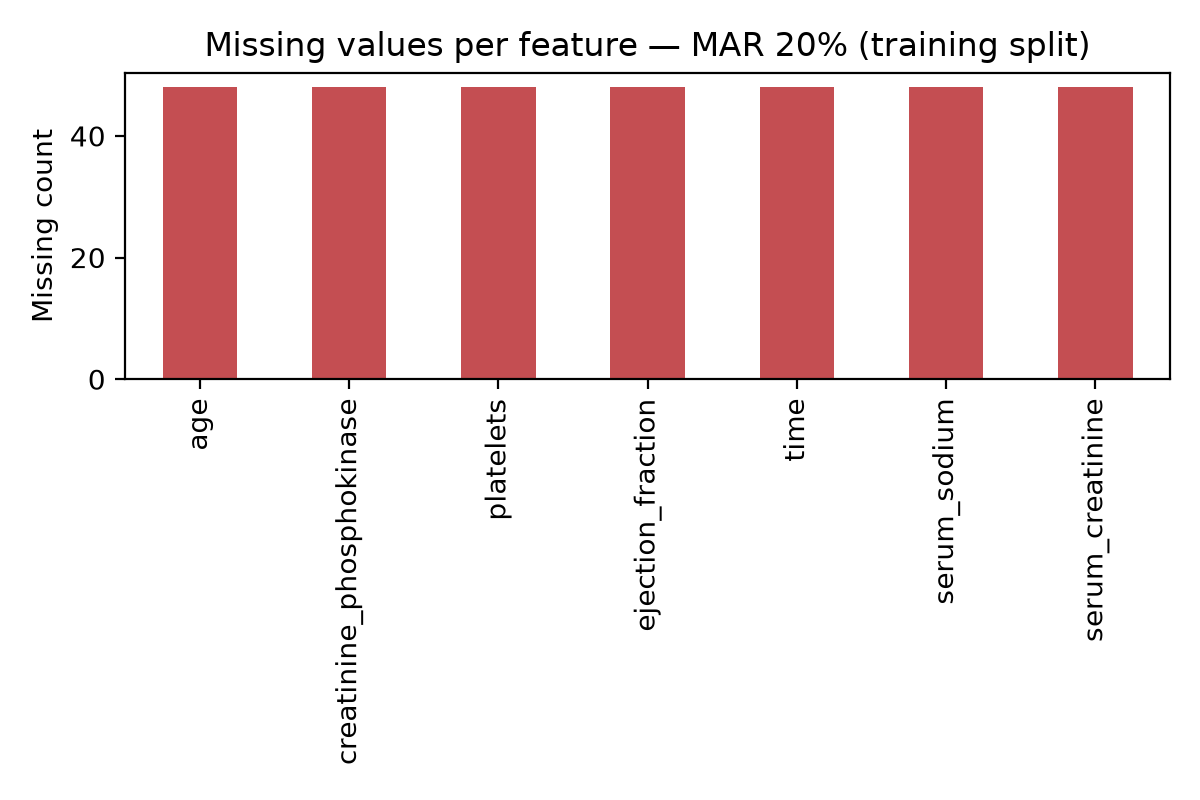

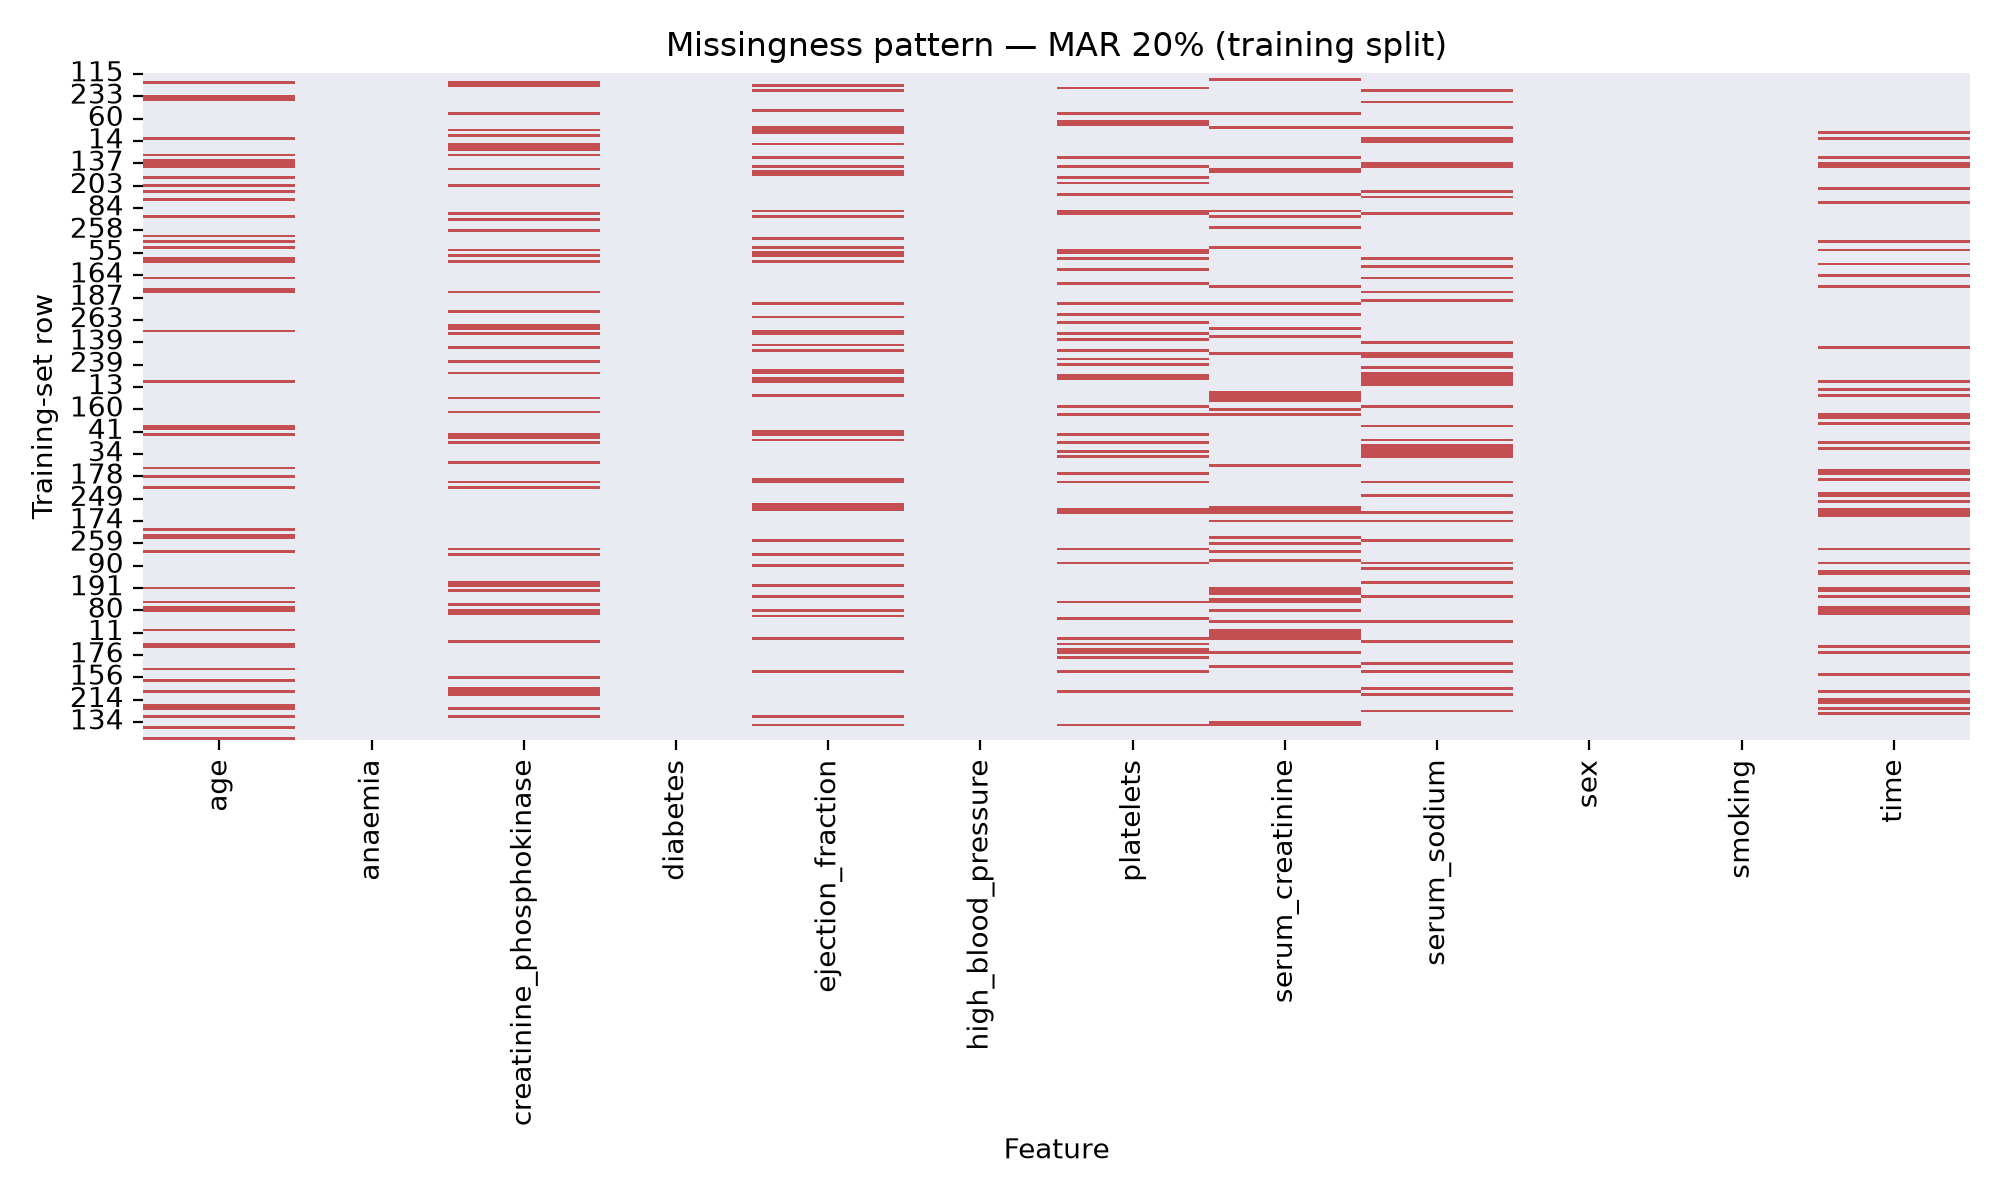

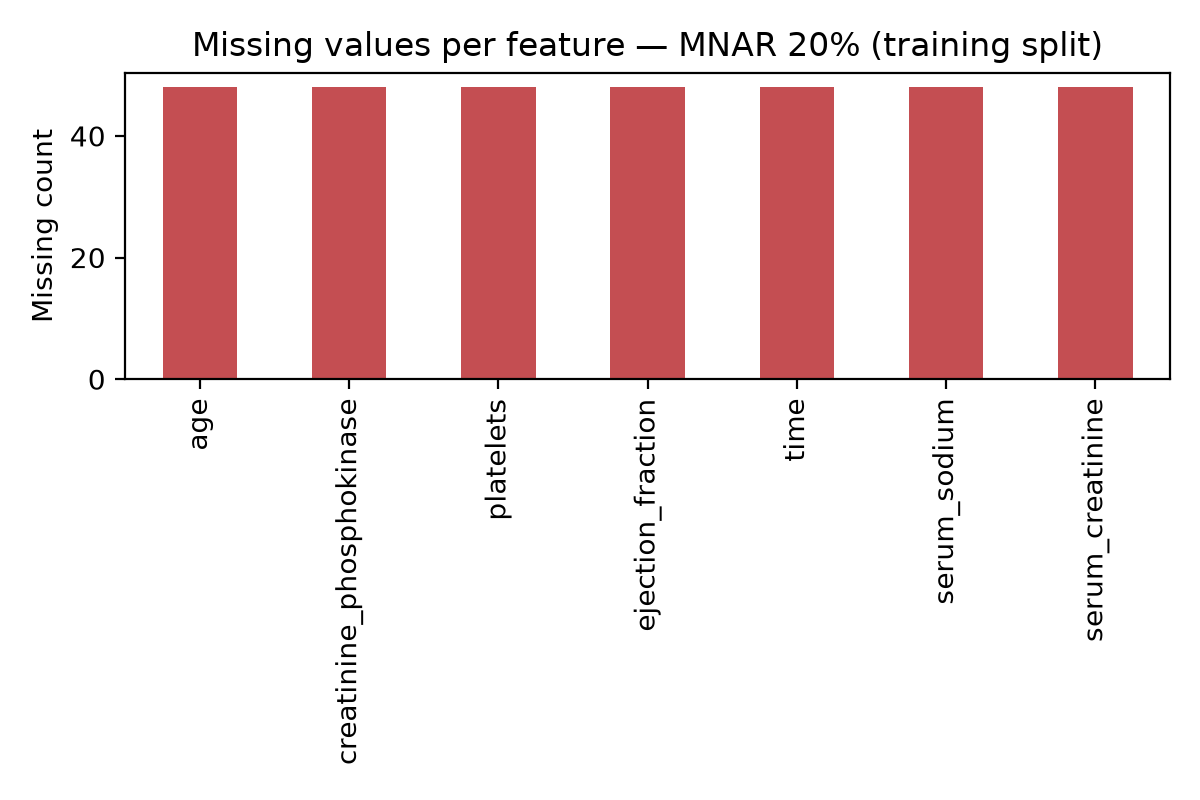

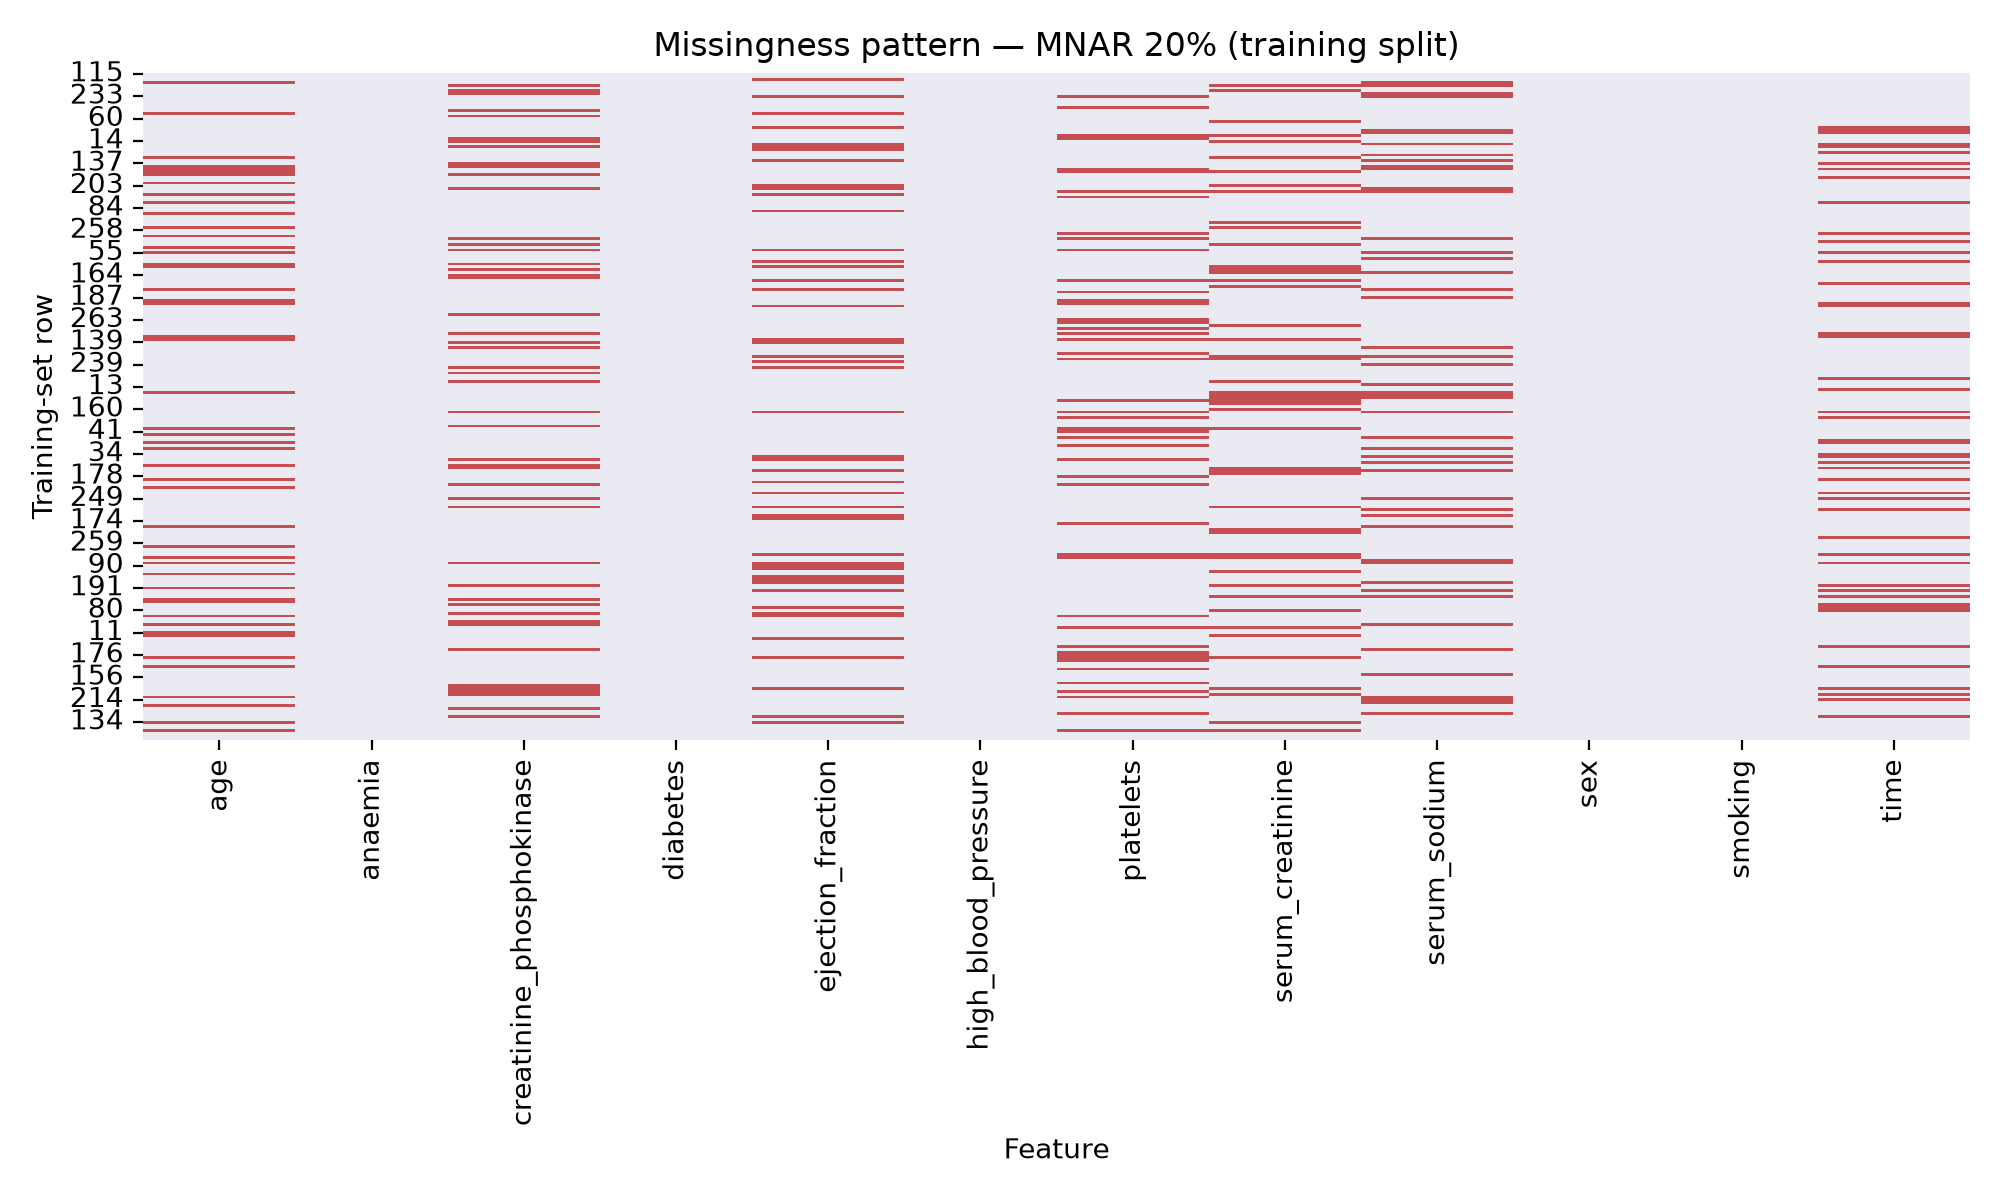

In [3]:
for mech in ["mcar", "mar", "mnar"]:
    display(Image(filename=f"../results/figures/missing_per_feature_{mech}20.png"))
    display(Image(filename=f"../results/figures/missingness_heatmap_{mech}20.png"))